# Incremental Sales Attribution Engine

## Objective

Explain **why a promotion generated incremental sales**, where
`incremental_sales = actual_sales - baseline_prediction`.

This notebook does **not** rebuild the baseline model and does **not** recompute
incremental sales. It explains the already-observed incremental impact:

1. builds a leakage-free `(product, promotion period)` dataset,
2. trains a simple explainable model (LightGBM / XGBoost / CatBoost) on the
   incremental-sales target,
3. explains every prediction with SHAP,
4. aggregates SHAP contributions into six business reasons,
5. emits a **complete attribution report** (all reasons) plus a **Top-K
   executive summary**, and
6. quantifies uncertainty (missing stock, limited date features, weak
   explanation concentration).

## Problem definition

| Item | Value |
|---|---|
| Unit of analysis | one row = one (product, promotion period) |
| Target | `incremental_sales` (taken as given from the platform) |
| Explanatory features | 42 features grouped into 6 business reasons |
| Output | complete attribution report + Top-K summary + confidence/uncertainty |

## Honesty rules

- The attribution model is an *explanation* model, **not** a causal estimator.
- Embeddings identify product *relationships*, not causes.
- "Similar-product sales changed during the promotion" is an observed
  relationship, never a causal claim.
- Missing stock / date information reduces confidence instead of being
  silently ignored.

```
Promotion period
   |
   v
Actual sales - baseline prediction   (platform baseline, unchanged)
   |
   v
incremental_sales                    (target, taken as given)
   |
   v
Attribution model -> SHAP (TreeExplainer)
   |
   v
Reason aggregation (6 business reasons, ALL reported)
   |
   v
Complete attribution report -> Top-K executive summary + uncertainty
```

## 1. Inputs and leakage policy

**Inputs (read-only):**
- `data/raw/transaction_data.csv` — baskets, quantities, prices, discounts
- `data/raw/product.csv` — department / commodity / sub-commodity / brand / manufacturer
- `data/raw/causal_data.csv` (cached at `data/processed/causal_weekly.parquet`) — display / mailer
- `data/raw/campaign_desc.csv` + `coupon.csv` — campaign types
- `outputs/baseline_engine/` — baseline predictions (summed to product x week); **not retrained**
- `outputs/product_embeddings/top_k_substitutes.parquet` — existing embeddings (**not rebuilt**)

**Missing data:** stock availability and complete calendar effects do not exist
in the platform. They are modelled as explicit limitation features that lower
confidence, never as silent claims.

**Leakage policy** (enforced by the `check_leakage` cell):
- every feature is tagged `pre` (available before the promotion decision),
  `during` (known while the promotion runs) or `static` (product descriptors);
- `pre` features are trailing windows that end before the promotion starts
  (reference week = period start - 1);
- no future information: no post-promotion sales, no future customer/category
  behaviour, no outcome-derived features (the target or same-week actual sales
  never appear as features);
- the split is temporal (by period start week); imputation statistics are
  computed on the fit split only.

## 2. Imports and Configuration

In [1]:
%matplotlib inline
import json
import os
from collections import Counter
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Paths ---
ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw" / "transaction_data.csv").exists():
    ROOT = next(p for p in ROOT.parents if (p / "data" / "raw" / "transaction_data.csv").exists())
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
BASELINE_DIR = ROOT / "outputs" / "baseline_engine"
EMBEDDING_DIR = ROOT / "outputs" / "product_embeddings"
SMOKE = os.environ.get("ATTRIBUTION_SMOKE") == "1"
OUTPUT_DIR = ROOT / "outputs" / ("attribution_smoke" if SMOKE else "attribution_engine")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Analysis window and temporal splits ---
# The baseline engine trains on weeks 1-79; this notebook explains weeks 80-101.
ANALYSIS_LO, ANALYSIS_HI = 80, 101          # post-training weeks explained here
SPLIT_FIT_END = 89                          # fit on periods starting <= 89
SPLIT_VAL = (90, 92)                        # early-stopping validation
SPLIT_TEST_START = 93                       # held-out test periods
HISTORY_END = 79                            # static per-product features use weeks <= 79
CO_PURCHASE_END = 79                        # co-purchase baskets: strictly pre-analysis
TOP_SUBSTITUTES = 10                        # top-K substitutes from the embedding model

# --- Model and reproducibility ---
SEED = 42
np.random.seed(SEED)
MODEL_N_ESTIMATORS = 500 if not SMOKE else 80
EVALUATION_SAMPLE = 1500 if not SMOKE else 300

CONFIG = {
    "analysis_window": [ANALYSIS_LO, ANALYSIS_HI],
    "split_fit_end": SPLIT_FIT_END,
    "split_val": list(SPLIT_VAL),
    "split_test_start": SPLIT_TEST_START,
    "history_end": HISTORY_END,
    "co_purchase_end": CO_PURCHASE_END,
    "top_substitutes": TOP_SUBSTITUTES,
    "seed": SEED,
    "smoke": SMOKE,
}
print("config:", json.dumps(CONFIG))

config: {"analysis_window": [80, 101], "split_fit_end": 89, "split_val": [90, 92], "split_test_start": 93, "history_end": 79, "co_purchase_end": 79, "top_substitutes": 10, "seed": 42, "smoke": false}


## 3. Data Loading

In [2]:
# 3a. Transactions and product metadata
TRANSACTION_COLUMNS = ["household_key", "BASKET_ID", "DAY", "PRODUCT_ID", "QUANTITY",
                       "SALES_VALUE", "STORE_ID", "RETAIL_DISC", "WEEK_NO"]
transactions = pd.read_csv(RAW_DIR / "transaction_data.csv", usecols=TRANSACTION_COLUMNS)
transactions = transactions[transactions["WEEK_NO"] <= ANALYSIS_HI]
product_meta = pd.read_csv(RAW_DIR / "product.csv")

print(f"transactions: {len(transactions):,} rows | weeks {transactions.WEEK_NO.min()}-{transactions.WEEK_NO.max()}")
print(f"products: {product_meta.PRODUCT_ID.nunique():,} | stores: {transactions.STORE_ID.nunique():,} | baskets: {transactions.BASKET_ID.nunique():,}")
print(f"transaction columns: {list(transactions.columns)}")
print(f"product metadata columns: {list(product_meta.columns)}")

transactions: 2,573,309 rows | weeks 1-101
products: 92,353 | stores: 581 | baskets: 274,101
transaction columns: ['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'WEEK_NO']
product metadata columns: ['PRODUCT_ID', 'MANUFACTURER', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']


In [3]:
# 3b. Display / mailer support and coupon campaigns (product x week)
try:
    display_mailer = pd.read_parquet(PROCESSED_DIR / "causal_weekly.parquet")
except FileNotFoundError:
    causal_raw = pd.read_csv(RAW_DIR / "causal_data.csv",
                             usecols=["PRODUCT_ID", "STORE_ID", "WEEK_NO", "display", "mailer"])
    causal_raw["mailer_on"] = causal_raw["mailer"].astype(str).ne("0").astype(int)
    display_mailer = (causal_raw.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
                      .agg(display=("display", lambda s: (s > 0).mean()),
                           mailer=("mailer_on", "mean")))
    display_mailer.to_parquet(PROCESSED_DIR / "causal_weekly.parquet", index=False)
display_mailer = display_mailer.rename(columns={"display_share": "display", "mailer_share": "mailer"})
display_mailer = display_mailer[display_mailer["WEEK_NO"] <= ANALYSIS_HI]

# coupon campaigns -> campaign type per product x week (day -> week mapping from transactions)
campaign_desc = pd.read_csv(RAW_DIR / "campaign_desc.csv")
day_to_week = transactions.groupby("DAY")["WEEK_NO"].agg(lambda s: s.mode().iloc[0])
max_day = int(max(transactions["DAY"].max(), campaign_desc[["START_DAY", "END_DAY"]].to_numpy().max()))
day_to_week = day_to_week.reindex(range(1, max_day + 1)).ffill().astype(int)
campaign_desc["start_week"] = campaign_desc["START_DAY"].map(day_to_week).astype(int)
campaign_desc["end_week"] = campaign_desc["END_DAY"].map(day_to_week).astype(int)

coupon = pd.read_csv(RAW_DIR / "coupon.csv", usecols=["PRODUCT_ID", "CAMPAIGN"]).drop_duplicates()
product_campaign = coupon.merge(campaign_desc[["CAMPAIGN", "DESCRIPTION", "start_week", "end_week"]],
                                on="CAMPAIGN")
starts = product_campaign["start_week"].to_numpy()
ends = np.minimum(product_campaign["end_week"].to_numpy(), ANALYSIS_HI)
n_weeks = (ends - starts + 1).clip(min=0)
active = n_weeks > 0
campaign_weekly = pd.DataFrame({
    "PRODUCT_ID": np.repeat(product_campaign["PRODUCT_ID"].to_numpy()[active], n_weeks[active]),
    "WEEK_NO": np.concatenate([np.arange(s, e + 1) for s, e in zip(starts[active], ends[active])]),
    "TYPE": np.repeat(product_campaign["DESCRIPTION"].to_numpy()[active], n_weeks[active]),
})
campaign_weekly["campaign_type"] = campaign_weekly["TYPE"].map({"TypeA": 1, "TypeB": 2, "TypeC": 3}).fillna(0).astype(int)
campaign_weekly = (campaign_weekly.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)
                   .agg(n_campaigns=("TYPE", "count"), campaign_type=("campaign_type", "max")))

print(f"display/mailer product-weeks: {len(display_mailer):,} | campaign product-weeks: {len(campaign_weekly):,}")

display/mailer product-weeks: 2,049,187 | campaign product-weeks: 780,304


In [4]:
# 3c. Platform baseline predictions (read-only; the baseline model is NOT retrained here)
baseline_feature_list = json.loads((BASELINE_DIR / "feature_list.json").read_text())
BASELINE_FEATURES = baseline_feature_list["features"]
BASELINE_CATEGORIES = baseline_feature_list["cat_cols_encoded"]
panel = pd.read_parquet(BASELINE_DIR / "panel.parquet")
panel_matrix = panel[BASELINE_FEATURES].copy()
for col in BASELINE_CATEGORIES:
    panel_matrix[col] = panel_matrix[col].astype("category")
hurdle_model = joblib.load(BASELINE_DIR / "model_stage1.pkl")
count_model = joblib.load(BASELINE_DIR / "model_stage2.pkl")
panel["baseline_qty"] = hurdle_model.predict_proba(panel_matrix)[:, 1] * count_model.predict(panel_matrix)
baseline_weekly = panel.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["baseline_qty"].sum()
del panel, panel_matrix

analysis_products = np.sort(baseline_weekly["PRODUCT_ID"].unique())
if SMOKE:
    analysis_products = analysis_products[:400]
print(f"baseline product-weeks: {len(baseline_weekly):,} | analysis products: {len(analysis_products):,}")

baseline product-weeks: 266,337 | analysis products: 2,637


## 4. Data Validation

In [5]:
# 4. Data Validation — basic integrity checks before feature engineering
missing_values = pd.DataFrame({
    "column": TRANSACTION_COLUMNS,
    "n_missing": [int(transactions[col].isna().sum()) for col in TRANSACTION_COLUMNS],
})
missing = missing_values[missing_values["n_missing"] > 0]
print("missing values in transactions:", "none" if missing.empty else "\n" + missing.to_string(index=False))

validation_checks = {
    "no null keys in transactions": int(transactions[["PRODUCT_ID", "WEEK_NO", "BASKET_ID", "STORE_ID"]].isna().sum().sum()) == 0,
    "no exact duplicate transaction rows": int(transactions.duplicated().sum()) == 0,
    "no negative quantity": not bool((transactions["QUANTITY"] < 0).any()),
    "no negative sales value": not bool((transactions["SALES_VALUE"] < 0).any()),
    "weeks within calendar range": 1 <= int(transactions["WEEK_NO"].min()) <= int(transactions["WEEK_NO"].max()) <= ANALYSIS_HI,
    "product metadata complete": int(product_meta.isna().sum().sum()) == 0,
    "baseline predictions non-negative": float(baseline_weekly["baseline_qty"].min()) >= 0.0,
}
validation_report = pd.DataFrame({"check": validation_checks.keys(), "passed": validation_checks.values()})
print(validation_report.to_string(index=False))
assert validation_report["passed"].all(), "data validation failed" 

missing values in transactions: none


                              check  passed
       no null keys in transactions    True
no exact duplicate transaction rows    True
               no negative quantity    True
            no negative sales value    True
        weeks within calendar range    True
          product metadata complete    True
  baseline predictions non-negative    True


## 5. Feature Engineering

In [6]:
# 5a. Product x week sales frame (continuous grid, zero-filled) with incremental target
def build_weekly_sales(transactions, products, baseline_weekly):
    sales = transactions[transactions["PRODUCT_ID"].isin(products)].copy()
    sales["unit_price"] = sales["SALES_VALUE"] / sales["QUANTITY"].where(sales["QUANTITY"] > 0)
    sales.loc[sales["unit_price"] < 0, "unit_price"] = np.nan
    sales["promo"] = (sales["RETAIL_DISC"] < 0).astype("int8")  # platform definition of a promo week
    discount_depth = (sales[sales["promo"] == 1].groupby(["PRODUCT_ID", "WEEK_NO"])["RETAIL_DISC"]
                      .mean().rename("disc_depth_raw"))

    weekly = sales.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False).agg(
        qty=("QUANTITY", "sum"),
        sales_value=("SALES_VALUE", "sum"),
        n_households=("household_key", "nunique"),
        n_baskets=("BASKET_ID", "nunique"),
        promo=("promo", "max"),
        unit_price=("unit_price", "median"),
    )
    weekly = weekly.merge(discount_depth, on=["PRODUCT_ID", "WEEK_NO"], how="left")
    weekly["disc_depth"] = (-weekly["disc_depth_raw"]).fillna(0.0).clip(lower=0.0)
    weekly = weekly.drop(columns=["disc_depth_raw"])

    # continuous calendar grid per product (weeks 1..ANALYSIS_HI), zero-filled
    grid = pd.MultiIndex.from_product([products, np.arange(1, ANALYSIS_HI + 1)],
                                      names=["PRODUCT_ID", "WEEK_NO"])
    weekly = weekly.set_index(["PRODUCT_ID", "WEEK_NO"]).reindex(grid).reset_index()
    for col in ["qty", "sales_value", "n_households", "n_baskets", "promo", "disc_depth"]:
        weekly[col] = weekly[col].fillna(0.0)

    weekly = weekly.merge(baseline_weekly, on=["PRODUCT_ID", "WEEK_NO"], how="left")
    weekly["baseline_qty"] = weekly["baseline_qty"].fillna(0.0)
    weekly["incremental"] = weekly["qty"] - weekly["baseline_qty"]  # target at week level (platform baseline)
    return weekly


weekly = build_weekly_sales(transactions, analysis_products, baseline_weekly)
weekly = weekly.merge(display_mailer, on=["PRODUCT_ID", "WEEK_NO"], how="left")
weekly = weekly.merge(campaign_weekly, on=["PRODUCT_ID", "WEEK_NO"], how="left")
weekly["date_limitation"] = weekly["display"].isna().astype(int)  # flag missing coverage BEFORE filling
for col in ["display", "mailer", "n_campaigns", "campaign_type"]:
    weekly[col] = weekly[col].fillna(0.0)
weekly["campaign_intensity"] = (weekly["display"] + weekly["mailer"]) / 2.0
weekly["stock_missing"] = 1  # the platform has no stock table -> explicit limitation flag
print(f"weekly grid: {len(weekly):,} product-weeks | {weekly.PRODUCT_ID.nunique():,} products")

weekly grid: 266,337 product-weeks | 2,637 products


In [7]:
# 5b. Static product-relationship features (existing embeddings — not rebuilt)
def build_static_relationship_features(products):
    substitutes = pd.read_parquet(EMBEDDING_DIR / "top_k_substitutes.parquet")
    substitutes = substitutes[substitutes["PRODUCT_ID"].isin(products)].copy()

    rows = []
    for k in range(1, TOP_SUBSTITUTES + 1):
        rows.append(pd.DataFrame({
            "PRODUCT_ID": substitutes["PRODUCT_ID"],
            "SIMILAR_PRODUCT_ID": substitutes[f"substitute_{k}"],
            "embedding_cosine": substitutes[f"substitute_similarity_{k}"],
            "substitute_score": substitutes[f"substitute_score_{k}"],
        }))
    all_pairs = (pd.concat(rows, ignore_index=True)
                 .dropna(subset=["SIMILAR_PRODUCT_ID"])
                 .astype({"SIMILAR_PRODUCT_ID": np.int64}))
    tracked_pairs = all_pairs[all_pairs["SIMILAR_PRODUCT_ID"].isin(products)].copy()

    metadata = product_meta.set_index("PRODUCT_ID")
    for col, key in [("sub_commodity_match", "SUB_COMMODITY_DESC"), ("brand_match", "BRAND"),
                     ("manufacturer_match", "MANUFACTURER"), ("commodity_match", "COMMODITY_DESC"),
                     ("department_match", "DEPARTMENT")]:
        all_pairs[col] = (all_pairs["PRODUCT_ID"].map(metadata[key]).to_numpy()
                          == all_pairs["SIMILAR_PRODUCT_ID"].map(metadata[key]).to_numpy()).astype(int)

    static_relationship = all_pairs.groupby("PRODUCT_ID").agg(
        emb_cosine_max=("embedding_cosine", "max"),
        emb_cosine_mean10=("embedding_cosine", "mean"),
        substitute_score_mean=("substitute_score", "mean"),
        sub_commodity_overlap=("sub_commodity_match", "mean"),
        commodity_overlap=("commodity_match", "mean"),
        brand_overlap=("brand_match", "mean"),
        manufacturer_overlap=("manufacturer_match", "mean"),
        department_overlap=("department_match", "mean"),
        n_substitutes=("SIMILAR_PRODUCT_ID", "count"),
    ).reset_index()
    return static_relationship, all_pairs, tracked_pairs


static_relationship, substitute_pairs, tracked_substitutes = build_static_relationship_features(analysis_products)
print(f"static relationship features: {static_relationship.shape} | tracked substitute pairs: {len(tracked_substitutes):,}")

static relationship features: (2637, 10) | tracked substitute pairs: 2,408


In [8]:
# 5c. Historical co-purchase strength (baskets in weeks <= CO_PURCHASE_END only; leakage-free)
# The saved similarity table has basket columns = 0 (embeddings are metadata-only),
# so co-purchase is computed directly from pre-analysis baskets.
def build_co_purchase_features(substitute_pairs):
    candidates = substitute_pairs.groupby("PRODUCT_ID")["SIMILAR_PRODUCT_ID"].agg(list).to_dict()
    pair_set = set()
    for product, similar in candidates.items():
        for other in similar:
            pair_set.add((int(product), int(other)) if int(product) < int(other) else (int(other), int(product)))

    basket_items = (transactions[transactions["WEEK_NO"] <= CO_PURCHASE_END]
                    .groupby("BASKET_ID")["PRODUCT_ID"]
                    .agg(lambda items: tuple(sorted({int(v) for v in items}))))
    pair_counts, basket_counts = Counter(), Counter()
    for items in basket_items:
        if not items:
            continue
        for product in items:
            basket_counts[product] += 1
        if len(items) < 2:
            continue
        for i in range(len(items) - 1):
            for j in range(i + 1, len(items)):
                a, b = items[i], items[j]
                key = (a, b) if a < b else (b, a)
                if key in pair_set:
                    pair_counts[key] += 1

    co_prob = {}
    for product, similar in candidates.items():
        n_baskets = basket_counts.get(int(product), 0)
        co_prob[int(product)] = [
            pair_counts.get((int(product), int(other)) if int(product) < int(other)
                            else (int(other), int(product)), 0) / max(n_baskets, 1)
            for other in similar
        ]
    co_purchase = pd.DataFrame({
        "PRODUCT_ID": list(co_prob.keys()),
        "co_purchase_top10_mean": [float(np.mean(v)) for v in co_prob.values()],
        "co_purchase_top5_mean": [float(np.mean(v[:5])) if v else np.nan for v in co_prob.values()],
        "co_purchase_breadth": [float(np.mean([x > 0 for x in v])) if v else np.nan for v in co_prob.values()],
    })
    return co_purchase, len(basket_items)


co_purchase, n_baskets_used = build_co_purchase_features(substitute_pairs)
print(f"co-purchase features: {co_purchase.shape} | baskets used (weeks <= {CO_PURCHASE_END}): {n_baskets_used:,}")

co-purchase features: (2637, 4) | baskets used (weeks <= 79): 209,536


In [9]:
# 5d. Category (sub-commodity) weekly demand for growth features
category_map = product_meta[["PRODUCT_ID", "SUB_COMMODITY_DESC"]].dropna().drop_duplicates("PRODUCT_ID")
category_weekly = (transactions[["PRODUCT_ID", "WEEK_NO", "QUANTITY"]]
                   .merge(category_map, on="PRODUCT_ID", how="inner")
                   .groupby(["SUB_COMMODITY_DESC", "WEEK_NO"], as_index=False)["QUANTITY"]
                   .sum().rename(columns={"QUANTITY": "cat_qty"}))

weekly = weekly.merge(category_map, on="PRODUCT_ID", how="left")
weekly = weekly.merge(category_weekly, on=["SUB_COMMODITY_DESC", "WEEK_NO"], how="left")
weekly["cat_qty"] = weekly["cat_qty"].fillna(0.0)
print(f"category-weeks: {len(category_weekly):,} | sub-categories: {category_weekly.SUB_COMMODITY_DESC.nunique():,}")

category-weeks: 133,543 | sub-categories: 2,382


In [10]:
# 5e. Historical price elasticity and discount response (weeks <= HISTORY_END; static per product)
history = weekly[weekly["WEEK_NO"] <= HISTORY_END]

def estimate_elasticity(group):
    data = group.loc[(group["unit_price"] > 0) & (group["qty"] > 0), ["unit_price", "qty"]].dropna()
    if len(data) < 6:
        return np.nan
    x = np.log(data["unit_price"].to_numpy(dtype=float))
    y = np.log(data["qty"].to_numpy(dtype=float))
    if not (np.isfinite(x).all() and np.isfinite(y).all()) or np.std(x) < 1e-9:
        return np.nan  # constant price or invalid values -> no estimable elasticity
    try:
        return float(np.polyfit(x, y, 1)[0])
    except np.linalg.LinAlgError:
        return np.nan


def estimate_discount_response(group):
    promo_mean = group.loc[group["promo"] == 1, "qty"].mean()
    non_promo_mean = group.loc[group["promo"] == 0, "qty"].mean()
    if pd.isna(promo_mean) or pd.isna(non_promo_mean) or non_promo_mean <= 1e-9:
        return np.nan
    return float(promo_mean / non_promo_mean - 1.0)


price_history = (history.groupby("PRODUCT_ID", group_keys=False)
                 .apply(lambda g: pd.Series({
                     "hist_price_elasticity": estimate_elasticity(g),
                     "hist_discount_response": estimate_discount_response(g)}),
                        include_groups=False)
                 .reset_index())
weekly = weekly.merge(price_history, on="PRODUCT_ID", how="left")
print(f"products with estimable elasticity: {price_history['hist_price_elasticity'].notna().sum():,}")

products with estimable elasticity: 2,481


In [11]:
# 5f. Leakage-free trailing features (rolling windows END at week w; periods read them at start - 1)
def add_trailing_features(frame):
    frame = frame.sort_values(["PRODUCT_ID", "WEEK_NO"]).copy()
    grouped = frame.groupby("PRODUCT_ID", group_keys=False)
    frame["hist_qty_rmean8"] = grouped["qty"].transform(lambda s: s.rolling(8, min_periods=3).mean())
    frame["hist_qty_rmean4"] = grouped["qty"].transform(lambda s: s.rolling(4, min_periods=2).mean())
    frame["hist_qty_cv8"] = (grouped["qty"].transform(lambda s: s.rolling(8, min_periods=4).std())
                             / (grouped["qty"].transform(lambda s: s.rolling(8, min_periods=4).mean()) + 1e-6))
    frame["hist_qty_cv8"] = frame["hist_qty_cv8"].clip(upper=5.0)
    frame["hist_households_rmean8"] = grouped["n_households"].transform(lambda s: s.rolling(8, min_periods=3).mean())
    frame["hist_households_rmean16"] = grouped["n_households"].transform(lambda s: s.rolling(16, min_periods=4).mean())
    frame["household_growth_8v16"] = frame["hist_households_rmean8"] / (frame["hist_households_rmean16"] + 1e-6) - 1.0
    frame["hist_baskets_rmean8"] = grouped["n_baskets"].transform(lambda s: s.rolling(8, min_periods=3).mean())
    frame["hist_baskets_rmean16"] = grouped["n_baskets"].transform(lambda s: s.rolling(16, min_periods=4).mean())
    frame["hist_purchase_freq"] = frame["hist_baskets_rmean8"] / (frame["hist_households_rmean8"] + 1e-6)
    frame["hist_basket_size"] = frame["hist_qty_rmean8"] / (frame["hist_baskets_rmean8"] + 1e-6)
    frame["hist_sales_rmean8"] = grouped["sales_value"].transform(lambda s: s.rolling(8, min_periods=3).mean())
    frame["hist_basket_value"] = frame["hist_sales_rmean8"] / (frame["hist_baskets_rmean8"] + 1e-6)
    frame["hist_promo_freq_12w"] = grouped["promo"].transform(lambda s: s.rolling(12, min_periods=4).mean())
    frame["promo_qty"] = frame["qty"].where(frame["promo"] == 1)
    frame["nopromo_qty"] = frame["qty"].where(frame["promo"] == 0)
    frame["hist_promo_qty_12w"] = grouped["promo_qty"].transform(lambda s: s.rolling(12, min_periods=4).sum())
    frame["hist_nopromo_qty_12w"] = grouped["nopromo_qty"].transform(lambda s: s.rolling(12, min_periods=4).sum())
    frame["hist_promo_uplift_12w"] = (frame["hist_promo_qty_12w"] / (frame["hist_nopromo_qty_12w"] + 1e-9) - 1.0).clip(-1.0, 10.0)
    frame["hist_disc_depth_12w"] = grouped["disc_depth"].transform(
        lambda s: s.where(s > 0).rolling(12, min_periods=2).mean())
    frame["price_before"] = grouped["unit_price"].transform(
        lambda s: s.where(s > 0).rolling(8, min_periods=3).median())
    frame["hist_active_weeks_26"] = grouped["qty"].transform(
        lambda s: (s > 0).astype(int).rolling(26, min_periods=1).sum())
    frame["cat_rmean8"] = grouped["cat_qty"].transform(lambda s: s.rolling(8, min_periods=3).mean())
    frame["cat_rmean16"] = grouped["cat_qty"].transform(lambda s: s.rolling(16, min_periods=4).mean())
    frame["cat_growth_8v16"] = frame["cat_rmean8"] / (frame["cat_rmean16"] + 1e-9) - 1.0
    return frame


weekly = add_trailing_features(weekly)
print("trailing features added")

trailing features added


In [12]:
# 5g. Similar-product sales series (cannibalization evidence; observed DURING the promotion)
def build_similar_product_sales(tracked_substitutes, weekly, products):
    similar_sales = (tracked_substitutes[["PRODUCT_ID", "SIMILAR_PRODUCT_ID"]]
                     .merge(weekly[["PRODUCT_ID", "WEEK_NO", "qty"]],
                            left_on="SIMILAR_PRODUCT_ID", right_on="PRODUCT_ID", how="inner")
                     .rename(columns={"PRODUCT_ID_x": "PRODUCT_ID", "PRODUCT_ID_y": "SIMILAR_PRODUCT_ID"}))
    similar_sales = (similar_sales.groupby(["PRODUCT_ID", "WEEK_NO"], as_index=False)["qty"]
                     .sum().rename(columns={"qty": "sub_qty"}))

    grid = pd.MultiIndex.from_product([products, np.arange(1, ANALYSIS_HI + 1)],
                                      names=["PRODUCT_ID", "WEEK_NO"])
    similar_sales = similar_sales.set_index(["PRODUCT_ID", "WEEK_NO"]).reindex(grid).reset_index()
    similar_sales["sub_qty"] = similar_sales["sub_qty"].fillna(0.0)
    grouped = similar_sales.groupby("PRODUCT_ID", group_keys=False)
    similar_sales["sub_qty_rmean8"] = grouped["sub_qty"].transform(lambda s: s.rolling(8, min_periods=3).mean())
    similar_sales["sub_qty_rmean4"] = grouped["sub_qty"].transform(lambda s: s.rolling(4, min_periods=2).mean())
    return similar_sales


similar_sales = build_similar_product_sales(tracked_substitutes, weekly, analysis_products)
weekly = weekly.merge(similar_sales, on=["PRODUCT_ID", "WEEK_NO"], how="left")
print("similar-product sales series merged")

similar-product sales series merged


In [13]:
# 5h. Promotion periods: contiguous promo runs per product, clipped to the analysis window
REFERENCE_FEATURES = ["price_before", "hist_qty_rmean8", "hist_qty_cv8", "hist_households_rmean8",
                      "household_growth_8v16", "hist_purchase_freq", "hist_baskets_rmean8",
                      "hist_basket_size", "hist_basket_value", "cat_growth_8v16", "hist_promo_freq_12w",
                      "hist_promo_uplift_12w", "hist_disc_depth_12w", "hist_active_weeks_26",
                      "date_limitation", "stock_missing", "sub_qty_rmean8", "sub_qty_rmean4"]


def build_promotion_periods(weekly, reference_features, static_relationship, co_purchase, price_history):
    weekly = weekly[weekly["WEEK_NO"].between(1, ANALYSIS_HI)].sort_values(["PRODUCT_ID", "WEEK_NO"]).copy()
    weekly["run_id"] = weekly.groupby("PRODUCT_ID")["promo"].diff().fillna(1.0).ne(0).cumsum()
    run_start = (weekly[weekly["promo"] == 1]
                 .groupby(["PRODUCT_ID", "run_id"])["WEEK_NO"].min().rename("true_start"))
    in_window = weekly[weekly["WEEK_NO"].between(ANALYSIS_LO, ANALYSIS_HI)]

    periods = (in_window[in_window["promo"] == 1]
               .groupby(["PRODUCT_ID", "run_id"], as_index=False)
               .agg(start_week=("WEEK_NO", "min"), end_week=("WEEK_NO", "max"),
                    actual_qty=("qty", "sum"), baseline_qty=("baseline_qty", "sum"),
                    incremental_sales=("incremental", "sum"),
                    discount_depth=("disc_depth", "mean"), display=("display", "mean"),
                    mailer=("mailer", "mean"), campaign_intensity=("campaign_intensity", "mean"),
                    n_campaigns=("n_campaigns", "mean"), promo_type=("campaign_type", "max"),
                    price_during=("unit_price", "median"), sub_qty_during=("sub_qty", "mean"),
                    date_limitation=("date_limitation", "max"))
               .merge(run_start, on=["PRODUCT_ID", "run_id"], how="left"))

    # keep runs overlapping the analysis window; clip period weeks to [80, 101]
    periods = periods[(periods["end_week"] >= ANALYSIS_LO) & (periods["start_week"] <= ANALYSIS_HI)].copy()
    periods["start_week"] = periods["start_week"].clip(lower=ANALYSIS_LO)
    periods["end_week"] = periods["end_week"].clip(upper=ANALYSIS_HI)
    periods["duration"] = periods["end_week"] - periods["start_week"] + 1
    periods["ref_week"] = periods["true_start"] - 1
    periods = periods[periods["ref_week"] >= 1].reset_index(drop=True)

    # pre-period features are read from the weekly frame at the reference week (start - 1)
    reference_rows = weekly[weekly["WEEK_NO"].isin(periods["ref_week"].unique())]
    reference_rows = reference_rows.set_index(["PRODUCT_ID", "WEEK_NO"])[reference_features].reset_index()
    periods = periods.merge(reference_rows, left_on=["PRODUCT_ID", "ref_week"],
                            right_on=["PRODUCT_ID", "WEEK_NO"], how="left")
    periods = periods.drop(columns=["WEEK_NO", "run_id", "true_start"])
    if "date_limitation_y" in periods.columns:  # keep the reference-week (pre-period) flag
        periods["date_limitation"] = periods["date_limitation_y"].fillna(0)
        periods = periods.drop(columns=["date_limitation_x", "date_limitation_y"])
    else:
        periods["date_limitation"] = periods["date_limitation"].fillna(0)
    periods = periods.rename(columns={"sub_qty_rmean8": "sub_qty_pre8", "sub_qty_rmean4": "sub_qty_pre4",
                                      "hist_qty_cv8": "demand_volatility"})
    periods["product_id"] = periods["PRODUCT_ID"]

    # derived (during) features
    periods["sub_sales_ratio_8w"] = np.where(periods["sub_qty_pre8"] > 1e-9,
                                             periods["sub_qty_during"] / periods["sub_qty_pre8"] - 1.0, np.nan)
    periods["sub_sales_ratio_4w"] = np.where(periods["sub_qty_pre4"] > 1e-9,
                                             periods["sub_qty_during"] / periods["sub_qty_pre4"] - 1.0, np.nan)
    periods["discount_pct"] = (periods["discount_depth"] / (periods["price_before"] + 1e-6)).clip(0.0, 1.0)
    periods["price_gap"] = (periods["price_before"] - periods["price_during"]).clip(lower=0.0)
    periods["price_gap_pct"] = (periods["price_gap"] / (periods["price_before"] + 1e-6)).clip(0.0, 2.0)
    periods["sparse_product"] = (periods["hist_active_weeks_26"] < 13).astype(int)
    periods["promotion_id"] = ("P" + periods["PRODUCT_ID"].astype(str) + "-" +
                               periods["start_week"].astype(str) + "-" + periods["end_week"].astype(str))
    periods["promo_type"] = periods["promo_type"].fillna(0).astype(int)

    # join static + co-purchase + historical price features
    periods = periods.merge(static_relationship, on="PRODUCT_ID", how="left")
    periods = periods.merge(co_purchase, on="PRODUCT_ID", how="left")
    periods = periods.merge(price_history, on="PRODUCT_ID", how="left")
    periods["hist_basket_count"] = periods["hist_baskets_rmean8"]
    periods = periods.drop(columns=["hist_baskets_rmean8", "sub_qty_during", "sub_qty_pre8", "sub_qty_pre4"])
    return periods


periods = build_promotion_periods(weekly, REFERENCE_FEATURES, static_relationship, co_purchase, price_history)
print(f"promotion periods: {len(periods):,} | products: {periods.PRODUCT_ID.nunique():,} | mean duration: {periods.duration.mean():.2f}w")
print(periods["incremental_sales"].describe(percentiles=[0.01, 0.5, 0.99]).round(2).to_string())

promotion periods: 5,478 | products: 1,903 | mean duration: 3.72w
count        5478.00
mean        11834.37
std        739473.57
min           -43.05
1%              0.58
50%             8.20
99%           519.56
max      54364616.26


In [14]:
# 5i. Feature registry: business reason -> {feature: (window, meaning)}
REASON_LABELS = {
    "promotion_effect": "Promotion effect",
    "cannibalization": "Cannibalization / substitution",
    "demand_expansion": "Demand expansion",
    "basket_expansion": "Basket expansion / halo",
    "price_response": "Price response",
    "unknown": "Unknown / data limitation",
}
REASON_ORDER = list(REASON_LABELS.keys())

FEATURE_REGISTRY = {
    "promotion_effect": {
        "discount_depth": ("during", "Mean retail discount depth ($) on promoted lines during the period"),
        "discount_pct": ("during", "Discount depth as a share of the pre-period regular price"),
        "promo_type": ("during", "Max coupon campaign type in the period (0 none, 1 A, 2 B, 3 C)"),
        "display": ("during", "Mean share of stores with display support during the period"),
        "mailer": ("during", "Mean share of stores with mailer support during the period"),
        "campaign_intensity": ("during", "Mean (display + mailer) exposure share during the period"),
        "n_campaigns": ("during", "Mean number of overlapping coupon campaigns per week"),
        "duration": ("during", "Promotion length in weeks (within the analysis window)"),
        "price_before": ("pre", "Median unit price over non-promoted weeks in [start-8, start-1]"),
        "price_during": ("during", "Median unit price during the promotion period"),
        "hist_promo_freq_12w": ("pre", "Share of promoted weeks in the 12 weeks before the promotion"),
        "hist_disc_depth_12w": ("pre", "Mean discount depth on promoted weeks in the 12 weeks before"),
        "hist_promo_uplift_12w": ("pre", "Promo vs non-promo weekly qty ratio - 1 in the 12 weeks before"),
    },
    "cannibalization": {
        "sub_sales_ratio_8w": ("during", "Similar-product weekly sales vs pre-period 8w mean - 1 (observed)"),
        "sub_sales_ratio_4w": ("during", "Similar-product weekly sales vs pre-period 4w mean - 1 (observed)"),
        "emb_cosine_max": ("static", "Max embedding cosine to any top-K substitute (metadata embeddings)"),
        "emb_cosine_mean10": ("static", "Mean embedding cosine to top-K substitutes"),
        "sub_commodity_overlap": ("static", "Share of top-K substitutes sharing the sub-commodity"),
        "commodity_overlap": ("static", "Share of top-K substitutes sharing the commodity"),
        "brand_overlap": ("static", "Share of top-K substitutes sharing the brand"),
        "manufacturer_overlap": ("static", "Share of top-K substitutes sharing the manufacturer"),
        "substitute_score_mean": ("static", "Mean substitute score of top-K substitutes"),
    },
    "demand_expansion": {
        "hist_households_rmean8": ("pre", "Trailing 8-week mean of weekly unique households"),
        "household_growth_8v16": ("pre", "8w vs 16w household growth rate before the promotion"),
        "cat_growth_8v16": ("pre", "Sub-commodity weekly qty growth, 8w vs 16w before the promotion"),
        "hist_purchase_freq": ("pre", "Trailing baskets per household (purchase frequency)"),
        "hist_basket_count": ("pre", "Trailing 8-week mean of weekly baskets"),
        "hist_qty_rmean8": ("pre", "Trailing 8-week mean of weekly product qty (demand scale)"),
    },
    "basket_expansion": {
        "co_purchase_top10_mean": ("pre", "Mean historical co-purchase probability with top-K substitutes"),
        "co_purchase_top5_mean": ("pre", "Mean historical co-purchase probability with top-5 substitutes"),
        "co_purchase_breadth": ("pre", "Share of top-K substitutes ever co-purchased historically"),
        "hist_basket_size": ("pre", "Trailing items per basket (basket size)"),
        "hist_basket_value": ("pre", "Trailing sales value per basket"),
    },
    "price_response": {
        "price_gap": ("during", "Pre-period regular price minus in-period median price"),
        "price_gap_pct": ("during", "Price gap as a share of the pre-period regular price"),
        "hist_price_elasticity": ("pre", "Product log-log price elasticity estimated on weeks <= 79"),
        "hist_discount_response": ("pre", "Product historical promo vs non-promo qty ratio - 1 (weeks <= 79)"),
    },
    "unknown": {
        "stock_missing": ("static", "1 = no stock table available (always 1 in this platform)"),
        "date_limitation": ("static", "1 = display/mailer coverage missing for the reference week"),
        "demand_volatility": ("pre", "Trailing coefficient of variation of weekly qty (unstable history)"),
        "sparse_product": ("static", "1 = fewer than 13 active weeks in the trailing 26 weeks"),
        "hist_active_weeks_26": ("pre", "Number of active weeks in the trailing 26 weeks"),
    },
}
FEATURE_COLUMNS = [feature for features in FEATURE_REGISTRY.values() for feature in features]
TARGET_COLUMN = "incremental_sales"

# feature documentation (meaning, calculation window, leakage tag)
feature_documentation = pd.DataFrame([
    {"feature": feature, "reason": reason, "window": window, "meaning": meaning}
    for reason, features in FEATURE_REGISTRY.items()
    for feature, (window, meaning) in features.items()
])
print(f"{len(FEATURE_COLUMNS)} features across {len(REASON_ORDER)} reasons:")
print(feature_documentation[["reason", "window", "feature"]].to_string(index=False))
feature_documentation.to_csv(OUTPUT_DIR / "feature_definitions.csv", index=False)

42 features across 6 reasons:
          reason window                feature
promotion_effect during         discount_depth
promotion_effect during           discount_pct
promotion_effect during             promo_type
promotion_effect during                display
promotion_effect during                 mailer
promotion_effect during     campaign_intensity
promotion_effect during            n_campaigns
promotion_effect during               duration
promotion_effect    pre           price_before
promotion_effect during           price_during
promotion_effect    pre    hist_promo_freq_12w
promotion_effect    pre    hist_disc_depth_12w
promotion_effect    pre  hist_promo_uplift_12w
 cannibalization during     sub_sales_ratio_8w
 cannibalization during     sub_sales_ratio_4w
 cannibalization static         emb_cosine_max
 cannibalization static      emb_cosine_mean10
 cannibalization static  sub_commodity_overlap
 cannibalization static      commodity_overlap
 cannibalization static       

In [15]:
# 5j. Leakage validation (temporal split, no future data, no outcome-derived features)
OUTCOME_COLUMNS = {"qty", "baseline_qty", "incremental", "incremental_sales", "actual_qty",
                   "sub_qty_during", "predicted"}


def check_leakage(periods, weekly, transactions, registry, sample_size=25, seed=SEED):
    violations = []
    for reason, features in registry.items():
        for feature, (window, _) in features.items():
            if feature in OUTCOME_COLUMNS:
                violations.append(f"outcome-derived feature in registry: {feature} ({reason})")
            if window not in ("pre", "during", "static"):
                violations.append(f"feature {feature} has disallowed window '{window}'")

    # independent recompute of trailing features from truncated history (weeks <= ref week)
    sample = periods.sample(n=min(sample_size, len(periods)), random_state=seed)
    trailing_checks = {
        "hist_qty_rmean8": ("qty", 8, "mean"),
        "hist_households_rmean8": ("n_households", 8, "mean"),
        "hist_basket_count": ("n_baskets", 8, "mean"),
        "hist_promo_freq_12w": ("promo", 12, "mean"),
        "hist_active_weeks_26": ("qty", 26, "active"),
        "price_before": ("unit_price", 8, "median_nonzero"),
    }
    max_diffs = {feature: 0.0 for feature in trailing_checks}
    n_checked = 0
    for period in sample.itertuples():
        product_id, ref_week = int(period.PRODUCT_ID), int(period.ref_week)
        history_rows = weekly[(weekly["PRODUCT_ID"] == product_id) & (weekly["WEEK_NO"] <= ref_week)]
        if history_rows.empty:
            continue
        n_checked += 1
        for feature, (source, window, kind) in trailing_checks.items():
            series = history_rows[source].tail(window)
            if kind == "mean":
                recomputed = series.mean()
            elif kind == "active":
                recomputed = float((series > 0).sum())
            else:
                recomputed = series.where(series > 0).median()
            stored = getattr(period, feature)
            if pd.notna(stored) and pd.notna(recomputed):
                max_diffs[feature] = max(max_diffs[feature], abs(float(stored) - float(recomputed)))

    # independent raw-transaction recompute for one trailing feature on a few periods
    tx_diffs = []
    for period in sample.head(5).itertuples():
        product_id, ref_week = int(period.PRODUCT_ID), int(period.ref_week)
        raw_mean = transactions[(transactions["PRODUCT_ID"] == product_id)
                                & (transactions["WEEK_NO"].between(ref_week - 7, ref_week))]["QUANTITY"].sum() / 8.0
        tx_diffs.append(abs(raw_mean - float(period.hist_qty_rmean8)))

    split_ok = (periods[periods["start_week"] <= SPLIT_FIT_END]["start_week"].max()
                < periods[periods["start_week"] >= SPLIT_TEST_START]["start_week"].min())
    return {
        "temporal_split_ok": bool(split_ok),
        "fit_max_start": int(periods[periods["start_week"] <= SPLIT_FIT_END]["start_week"].max()),
        "test_min_start": int(periods[periods["start_week"] >= SPLIT_TEST_START]["start_week"].min()),
        "violations": violations,
        "trailing_max_abs_diff": {k: float(v) for k, v in max_diffs.items()},
        "raw_tx_recompute_max_abs_diff": float(max(tx_diffs)) if tx_diffs else None,
        "periods_checked": n_checked,
        "all_windows_are_pre_during_or_static": len(violations) == 0,
    }


leakage_report = check_leakage(periods, weekly, transactions, FEATURE_REGISTRY)
print("temporal split ok:", leakage_report["temporal_split_ok"],
      f"(fit <= {leakage_report['fit_max_start']} | test >= {leakage_report['test_min_start']})")
print("violations:", leakage_report["violations"] or "none")
print("trailing recompute max abs diff:", {k: round(v, 6) for k, v in leakage_report["trailing_max_abs_diff"].items()})
print("raw-tx recompute max abs diff:", round(leakage_report["raw_tx_recompute_max_abs_diff"], 6))

temporal split ok: True (fit <= 89 | test >= 93)
violations: none
trailing recompute max abs diff: {'hist_qty_rmean8': 0.0, 'hist_households_rmean8': 0.0, 'hist_basket_count': 0.0, 'hist_promo_freq_12w': 0.0, 'hist_active_weeks_26': 0.0, 'price_before': 0.0}
raw-tx recompute max abs diff: 0.0


## 6. Train/Test Split

In [16]:
# 6. Modeling dataset: temporal split (fit <= 89, val 90-92, test >= 93) with fit-only statistics
MODEL_COLUMNS = list(dict.fromkeys(["promotion_id", "product_id", "start_week", "end_week", "duration",
                                    "actual_qty", "baseline_qty", TARGET_COLUMN] + FEATURE_COLUMNS))
data = periods[MODEL_COLUMNS].copy()
data["split"] = np.where(data["start_week"] <= SPLIT_FIT_END, "fit",
                 np.where(data["start_week"] <= SPLIT_VAL[1], "val", "test"))
imputed_flags = data[FEATURE_COLUMNS].isna().copy()

fit = data[data["split"] == "fit"]
imputation_medians = fit[FEATURE_COLUMNS].median().fillna(0.0)
data[FEATURE_COLUMNS] = data[FEATURE_COLUMNS].fillna(imputation_medians)

# winsorize the target on the fit distribution (extreme periods capped for model stability)
target_low, target_high = fit[TARGET_COLUMN].quantile([0.01, 0.99])
data["target_win"] = data[TARGET_COLUMN].clip(target_low, target_high)

print(f"fit  periods (start week <= {SPLIT_FIT_END}): {int((data['split'] == 'fit').sum()):,}")
print(f"val  periods (start week {SPLIT_VAL[0]}-{SPLIT_VAL[1]}): {int((data['split'] == 'val').sum()):,}")
print(f"test periods (start week >= {SPLIT_TEST_START}): {int((data['split'] == 'test').sum()):,}")
print(f"target winsorize bounds (fit): [{target_low:.1f}, {target_high:.1f}]")
print("imputed share per feature (top 10):")
print(imputed_flags.mean().sort_values(ascending=False).head(10).round(3).to_string())

fit  periods (start week <= 89): 2,882
val  periods (start week 90-92): 626
test periods (start week >= 93): 1,970
target winsorize bounds (fit): [0.6, 767.7]
imputed share per feature (top 10):


hist_promo_uplift_12w     0.527
sub_sales_ratio_4w        0.481
sub_sales_ratio_8w        0.476
hist_disc_depth_12w       0.164
price_gap                 0.054
price_gap_pct             0.054
discount_pct              0.054
price_before              0.054
hist_discount_response    0.045
hist_price_elasticity     0.011


## 7. Model Training

In [17]:
# 7. Attribution models (explanation models — NOT causal estimators)
def evaluate(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "wape": float(mean_absolute_error(y_true, y_pred) / (np.abs(y_true).mean() + 1e-9)),
    }


X_fit, y_fit = data[data["split"] == "fit"][FEATURE_COLUMNS], data[data["split"] == "fit"]["target_win"]
X_val, y_val = data[data["split"] == "val"][FEATURE_COLUMNS], data[data["split"] == "val"]["target_win"]
X_test, y_test = data[data["split"] == "test"][FEATURE_COLUMNS], data[data["split"] == "test"]["target_win"]

lightgbm_model = lgb.LGBMRegressor(
    n_estimators=MODEL_N_ESTIMATORS, learning_rate=0.03, num_leaves=31, min_child_samples=20,
    subsample=0.9, subsample_freq=1, colsample_bytree=0.9, random_state=SEED, n_jobs=-1, verbose=-1)
lightgbm_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)],
                   callbacks=[lgb.early_stopping(60, verbose=False)])

xgboost_model = xgb.XGBRegressor(
    n_estimators=MODEL_N_ESTIMATORS, learning_rate=0.03, max_depth=6, min_child_weight=5,
    subsample=0.9, colsample_bytree=0.9, random_state=SEED, n_jobs=-1, early_stopping_rounds=60)
xgboost_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

catboost_model = CatBoostRegressor(
    iterations=MODEL_N_ESTIMATORS, learning_rate=0.05, depth=6, l2_leaf_reg=5,
    random_seed=SEED, verbose=0)
catboost_model.fit(X_fit, y_fit, eval_set=(X_val, y_val), early_stopping_rounds=60, use_best_model=True)

models = {"lightgbm": lightgbm_model, "xgboost": xgboost_model, "catboost": catboost_model}
results = {name: {"val": evaluate(y_val, model.predict(X_val)),
                  "test": evaluate(y_test, model.predict(X_test))}
           for name, model in models.items()}

/home/mhseddighi/Projects/promotion-intelligence/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


## 8. Evaluation

In [18]:
# 8. Evaluation on the held-out test split
naive_mae = mean_absolute_error(y_test, np.full(len(y_test), y_fit.mean()))
results["naive_mean"] = {"test": {"mae": float(naive_mae), "rmse": np.nan, "wape": np.nan}}
best_name = min(["lightgbm", "xgboost", "catboost"], key=lambda name: results[name]["test"]["mae"])
best_model = models[best_name]

evaluation_table = pd.DataFrame({
    "model": list(results.keys()),
    "val_mae": [results[name].get("val", {}).get("mae") for name in results],
    "test_mae": [results[name].get("test", {}).get("mae") for name in results],
    "test_rmse": [results[name].get("test", {}).get("rmse") for name in results],
    "test_wape": [results[name].get("test", {}).get("wape") for name in results],
}).round(2)
print(evaluation_table.to_string(index=False))
print(f"best model (lowest test MAE): {best_name} | naive baseline (fit mean) test MAE: {naive_mae:.2f}")

     model  val_mae  test_mae  test_rmse  test_wape
  lightgbm    10.32      9.53      24.31       0.47
   xgboost     9.10      8.22      21.50       0.41
  catboost     9.17      8.13      21.56       0.41
naive_mean      NaN     37.45        NaN        NaN
best model (lowest test MAE): catboost | naive baseline (fit mean) test MAE: 37.45


## 9. Explainability

In [19]:
# 9a. SHAP values on a deterministic sample of the test split (TreeExplainer on the best model)
test_indices = data.index[data["split"] == "test"].to_numpy()
n_sample = min(EVALUATION_SAMPLE, len(test_indices))
sample_indices = np.random.RandomState(SEED).choice(test_indices, n_sample, replace=False)
sample = data.loc[sample_indices].copy()
sample_features = sample[FEATURE_COLUMNS]

explainer = shap.TreeExplainer(best_model)
shap_matrix = explainer.shap_values(sample_features)  # (n_periods, n_features), additive in prediction units
base_value = float(explainer.expected_value)
sample["predicted"] = best_model.predict(sample_features)
sample["residual"] = sample[TARGET_COLUMN] - sample["predicted"]

shap_additivity = float(np.max(np.abs(shap_matrix.sum(axis=1) + base_value - sample["predicted"].to_numpy())))
print(f"shap matrix: {shap_matrix.shape} | base value: {base_value:.2f} | additive check (max diff): {shap_additivity:.2e}")

shap matrix: (1500, 42) | base value: 42.85 | additive check (max diff): 1.02e-12


In [20]:
# 9b. Aggregate SHAP contributions into business reasons
def aggregate_reason_effects(shap_matrix, feature_columns, registry):
    return {reason: shap_matrix[:, [feature_columns.index(f) for f in features]].sum(axis=1)
            for reason, features in registry.items()}


reason_units = aggregate_reason_effects(shap_matrix, FEATURE_COLUMNS, FEATURE_REGISTRY)
# the unknown bucket absorbs the model base rate + limitation-feature SHAP + the prediction residual,
# so reason impacts reconcile exactly with the observed incremental sales
reason_units["unknown"] = reason_units["unknown"] + base_value + sample["residual"].to_numpy()

reason_table = pd.DataFrame({
    "reason": REASON_ORDER,
    "mean_units": [float(reason_units[reason].mean()) for reason in REASON_ORDER],
    "mean_abs_units": [float(np.abs(reason_units[reason]).mean()) for reason in REASON_ORDER],
})
reason_table["share_of_abs"] = reason_table["mean_abs_units"] / reason_table["mean_abs_units"].sum()
print(reason_table.round(2).to_string(index=False))

reason_df = pd.DataFrame(reason_units, index=sample.index)

          reason  mean_units  mean_abs_units  share_of_abs
promotion_effect      -23.97           28.65          0.11
 cannibalization       -0.01            0.38          0.00
demand_expansion        0.70           17.77          0.07
basket_expansion       -0.01            2.40          0.01
  price_response        0.08            2.46          0.01
         unknown      207.15          208.08          0.80


In [21]:
# 9c. Confidence scores and uncertainty statements
def compute_reason_consistency(reason_units):
    """Share of rows where each reason pushes in its dominant direction (SHAP stability)."""
    consistency = {}
    for reason in REASON_ORDER:
        values = reason_units[reason]
        consistency[reason] = float(max(np.mean(values > 1e-9), np.mean(values < -1e-9)))
    return consistency


def data_quality_score(imputed_share, stock_missing, date_limitation, sparse_product):
    return float(np.clip(1.0 - imputed_share - 0.15 * stock_missing - 0.10 * date_limitation
                         - 0.05 * sparse_product, 0.0, 1.0))


def reason_confidence(availability, consistency, prediction_reliability, data_quality, residual_share=None):
    score = float(np.clip(0.30 * availability + 0.30 * consistency + 0.20 * prediction_reliability
                          + 0.20 * data_quality, 0.0, 1.0))
    if residual_share is not None:  # unknown reason: unexplained residual further lowers confidence
        score *= float(np.clip(1.0 - 0.5 * min(1.0, residual_share), 0.0, 1.0))
    return score


def uncertainty_statements(row, overall_confidence, concentration):
    statements = []
    if row["stock_missing"]:
        statements.append("Stock availability is unavailable. Some sales changes may be caused by availability changes.")
    if row["date_limitation"]:
        statements.append("Seasonality cannot be completely separated (limited calendar/date features).")
    if concentration < 0.30:
        statements.append("Incremental sales detected but the main driver cannot be confidently identified.")
    if overall_confidence < 0.50:
        statements.append("Attribution confidence is low; treat reason contributions as directional only.")
    return statements


def report_confidences(row, residual_share):
    flags = imputed_flags.loc[row.name]
    availability = {reason: 1.0 - float(flags[list(FEATURE_REGISTRY[reason].keys())].mean())
                    for reason in REASON_ORDER}
    data_quality = data_quality_score(float(flags[FEATURE_COLUMNS].mean()), row["stock_missing"],
                                      row["date_limitation"], row["sparse_product"])
    confidences = {reason: reason_confidence(availability[reason], consistency[reason],
                                             prediction_reliability, data_quality,
                                             residual_share if reason == "unknown" else None)
                   for reason in REASON_ORDER}
    return confidences, data_quality


consistency = compute_reason_consistency(reason_units)
prediction_reliability = float(np.clip(1.0 - results[best_name]["test"]["wape"], 0.0, 1.0))
print("shap consistency per reason:", {reason: round(v, 3) for reason, v in consistency.items()})
print(f"prediction reliability (1 - test WAPE): {prediction_reliability:.3f}")

shap consistency per reason: {'promotion_effect': 0.933, 'cannibalization': 0.569, 'demand_expansion': 0.729, 'basket_expansion': 0.676, 'price_response': 0.621, 'unknown': 0.991}
prediction reliability (1 - test WAPE): 0.595


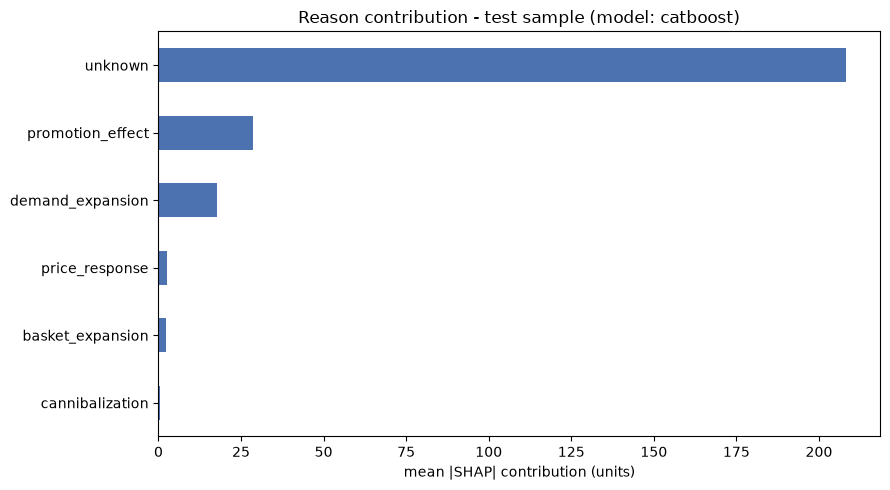

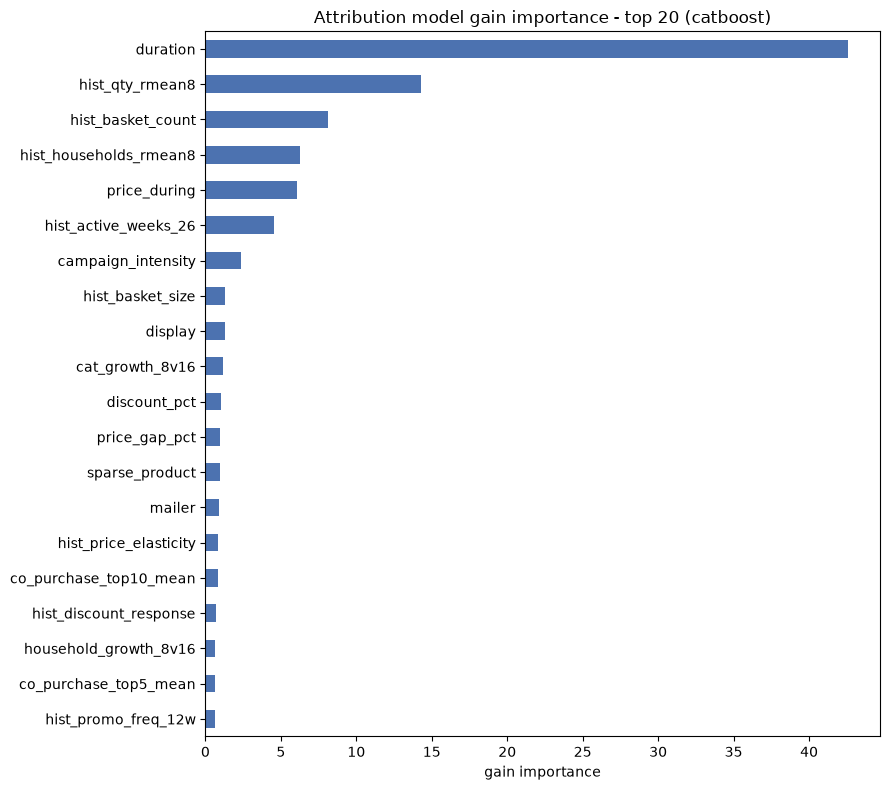

/tmp/ipykernel_1663958/1201443105.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_matrix, sample_features, feature_names=FEATURE_COLUMNS, max_display=15, show=False)


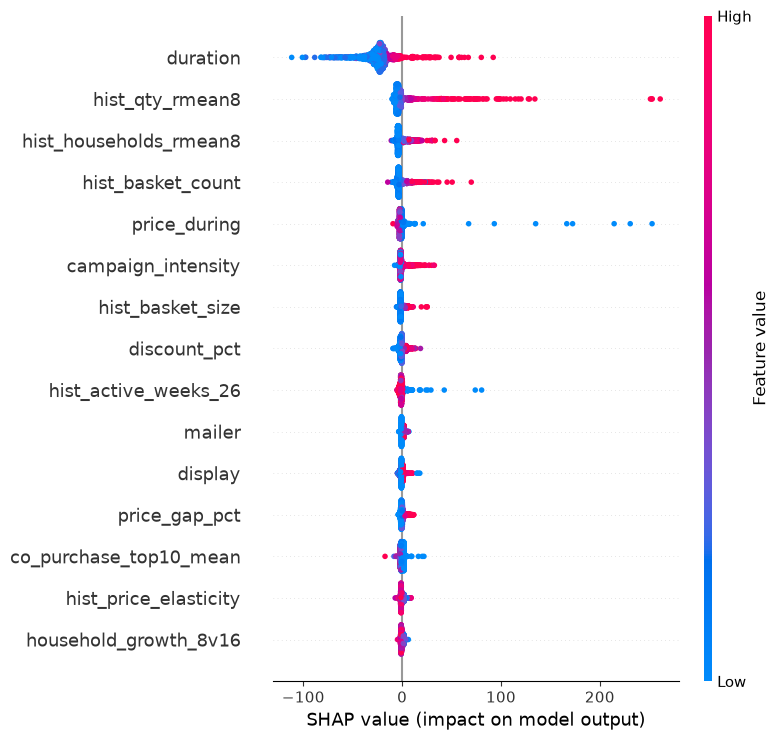

In [22]:
# 9d. Explainability plots
# reason contribution (test sample)
mean_abs = pd.Series({reason: float(np.abs(reason_units[reason]).mean()) for reason in REASON_ORDER})
fig, ax = plt.subplots(figsize=(9, 5))
mean_abs.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set(xlabel="mean |SHAP| contribution (units)", ylabel="",
       title=f"Reason contribution - test sample (model: {best_name})")
plt.tight_layout()
fig.savefig(FIG_DIR / "reason_contributions.png", dpi=140)
plt.show()

# feature gain importance (top 20)
importance = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
importance.tail(20).plot.barh(ax=ax, color="#4C72B0")
ax.set(title=f"Attribution model gain importance - top 20 ({best_name})", xlabel="gain importance")
plt.tight_layout()
fig.savefig(FIG_DIR / "feature_importance.png", dpi=140)
plt.show()

# SHAP summary
fig = plt.figure(figsize=(11, 8))
shap.summary_plot(shap_matrix, sample_features, feature_names=FEATURE_COLUMNS, max_display=15, show=False)
plt.tight_layout()
fig.savefig(FIG_DIR / "shap_summary.png", dpi=140)
plt.show()

## 10. Final Results

In [23]:
# 10a. Complete attribution report (ALL reasons) + Top-K executive summary
def row_value(row, name, default=np.nan):
    value = row.get(name, default)
    return default if value is None else value


def evidence_for_reason(reason, row, impact_units):
    evidence = []
    if reason == "promotion_effect":
        discount_pct = row_value(row, "discount_pct", 0)
        if discount_pct > 0.15:
            if discount_pct < 0.95:
                evidence.append(f"discount of {100 * discount_pct:.0f}% off regular price")
            else:
                evidence.append("deep discount applied (discount near or above the regular price)")
        if row_value(row, "display", 0) > 0.5:
            evidence.append("display campaign active")
        if row_value(row, "mailer", 0) > 0.5:
            evidence.append("mailer campaign active")
        if row_value(row, "promo_type", 0) > 0:
            evidence.append(f"coupon campaign type {int(row_value(row, 'promo_type', 0))}")
        if row_value(row, "duration", 1) > 1:
            evidence.append(f"promotion ran {int(row_value(row, 'duration', 1))} weeks")
        if row_value(row, "hist_promo_uplift_12w", 0) > 0.2:
            evidence.append("historically strong promotion response")
    elif reason == "cannibalization":
        if impact_units < 0 and row_value(row, "sub_sales_ratio_8w", 0) < -0.05:
            evidence.append(f"similar-product sales declined {100 * row_value(row, 'sub_sales_ratio_8w', 0):.0f}% "
                            "during the promotion")
        if row_value(row, "emb_cosine_max", 0) > 0.6:
            evidence.append(f"high embedding similarity to substitutes (cosine {row_value(row, 'emb_cosine_max', 0):.2f})")
        if row_value(row, "sub_commodity_overlap", 0) > 0.5:
            evidence.append("strong sub-category overlap with substitutes")
        if row_value(row, "brand_overlap", 0) > 0.5:
            evidence.append("many substitutes share the brand")
    elif reason == "demand_expansion":
        if row_value(row, "household_growth_8v16", 0) > 0.03:
            evidence.append(f"households growing {100 * row_value(row, 'household_growth_8v16', 0):.0f}% before the promotion")
        if row_value(row, "cat_growth_8v16", 0) > 0.03:
            evidence.append(f"category demand growing {100 * row_value(row, 'cat_growth_8v16', 0):.0f}%")
        if row_value(row, "hist_purchase_freq", 0) > 1.0:
            evidence.append("frequent repeat purchasing before the promotion")
    elif reason == "basket_expansion":
        if row_value(row, "co_purchase_top5_mean", 0) > 0.1:
            evidence.append("high historical co-purchase with related products")
        if row_value(row, "co_purchase_breadth", 0) > 0.5:
            evidence.append("related products frequently share baskets")
        if row_value(row, "hist_basket_size", 0) > 6:
            evidence.append("large historical basket size")
    elif reason == "price_response":
        if row_value(row, "price_gap_pct", 0) > 0.10:
            evidence.append(f"price {100 * row_value(row, 'price_gap_pct', 0):.0f}% below regular price during the promotion")
        if row_value(row, "hist_price_elasticity", 0) < -0.5:
            evidence.append(f"historically price-elastic demand (elasticity {row_value(row, 'hist_price_elasticity', 0):.2f})")
        if row_value(row, "hist_discount_response", 0) > 0.2:
            evidence.append("historically strong discount response")
    elif reason == "unknown":
        if row_value(row, "stock_missing", 0) == 1:
            evidence.append("stock information unavailable")
        if row_value(row, "date_limitation", 0) == 1:
            evidence.append("limited date features")
        if row_value(row, "demand_volatility", 0) > 0.8:
            evidence.append("unstable demand history")
        if row_value(row, "sparse_product", 0) == 1:
            evidence.append("sparse product history")
    return evidence


def limitations_for_reason(reason, row, impact_units):
    limitations = []
    if reason == "unknown" and abs(impact_units) > 1e-6:
        limitations.append("Impact exists but the reason cannot be confidently identified.")
    if reason != "unknown":
        if row_value(row, "stock_missing", 0) == 1:
            limitations.append("Stock availability is unavailable; some sales changes may be availability-driven.")
        if row_value(row, "date_limitation", 0) == 1:
            limitations.append("Seasonality cannot be completely separated.")
    return limitations


def build_report(row, units, predicted, confidences, overall_confidence, concentration, top_k=3):
    incremental = float(row[TARGET_COLUMN])
    if abs(incremental) > 1e-6 and abs(incremental) >= 0.1 * abs(predicted) + 1.0:
        denominator, percentage_base = incremental, "incremental_sales"
    else:
        denominator, percentage_base = abs(predicted) + 1e-6, "predicted_abs"
    reasons = []
    for reason in REASON_ORDER:
        impact = float(units[reason])
        reasons.append({
            "reason": reason,
            "label": REASON_LABELS[reason],
            "impact_units": round(impact, 2),
            "impact_percentage": round(impact / denominator * 100.0, 2),
            "confidence": round(float(confidences[reason]), 3),
            "evidence": evidence_for_reason(reason, row, impact),
            "limitations": limitations_for_reason(reason, row, impact),
        })
    top_reasons = [dict(r) for r in sorted(reasons, key=lambda r: abs(r["impact_units"]), reverse=True)[:top_k]]
    for rank, reason in enumerate(top_reasons, 1):
        reason["rank"] = rank
        reason["direction"] = "positive" if reason["impact_units"] >= 0 else "negative"
        reason["summary"] = (f"{reason['label']} {'added' if reason['impact_units'] >= 0 else 'reduced'} "
                             f"{abs(reason['impact_units']):.0f} units ({abs(reason['impact_percentage']):.0f}%)")
    return {
        "promotion_id": str(row["promotion_id"]),
        "product_id": int(row["product_id"]),
        "period": {"start_week": int(row["start_week"]), "end_week": int(row["end_week"]),
                   "duration": int(row["duration"])},
        "incremental_sales": round(incremental, 2),
        "actual_sales": round(float(row["actual_qty"]), 2),
        "baseline_sales": round(float(row["baseline_qty"]), 2),
        "predicted_incremental": round(float(predicted), 2),
        "percentage_base": percentage_base,
        "percentage_note": ("" if percentage_base == "incremental_sales"
                            else "Actual incremental is near zero relative to the prediction; "
                                 "percentages are relative to the predicted incremental."),
        "reason_attribution": reasons,
        "top_k_reasons": top_reasons,
        "confidence": {"overall": round(float(overall_confidence), 3),
                       "per_reason": {r["reason"]: r["confidence"] for r in reasons},
                       "components": {"prediction_reliability": round(prediction_reliability, 3)}},
        "explanation_concentration": round(float(concentration), 3),
        "uncertainty_statements": uncertainty_statements(row, overall_confidence, concentration),
        "data_quality_flags": {"stock_missing": int(row["stock_missing"]),
                               "date_limitation": int(row["date_limitation"]),
                               "sparse_product": int(row["sparse_product"])},
        "model": {"name": best_name, "evaluation_split": "test"},
    }


def executive_summary(report):
    top = report["top_k_reasons"]
    summary = (f"Promotion {report['promotion_id']} generated {report['incremental_sales']:,.0f} incremental units "
               f"({report['actual_sales']:,.0f} actual vs {report['baseline_sales']:,.0f} baseline). ")
    summary += "Top drivers: " + "; ".join(
        f"{r['rank']}. {r['label']} {r['impact_units']:+,.0f} units ({r['impact_percentage']:+.0f}%)" for r in top) + ". "
    if report["uncertainty_statements"]:
        summary += "Limitations: " + " ".join(report["uncertainty_statements"])
    return summary


def period_report(row, sample_frame):
    units = reason_df.loc[row.name].to_dict()
    residual_share = abs(sample_frame.loc[row.name, "residual"]) / (
        abs(sample_frame.loc[row.name, TARGET_COLUMN]) + 1e-6)
    confidences, _ = report_confidences(row, residual_share)
    concentration = max(abs(v) for v in units.values()) / (
        sum(abs(v) for v in units.values()) + 1e-9)
    overall_confidence = float(np.mean(list(confidences.values())))
    return build_report(row, units, sample_frame.loc[row.name, "predicted"],
                        confidences, overall_confidence, concentration)

In [24]:
# 10b. Example promotion explanations (one per key reason, drawn from the test sample)
incremental_abs = sample[TARGET_COLUMN].abs()
representative = ((incremental_abs >= incremental_abs.quantile(0.25))
                  & (incremental_abs <= incremental_abs.quantile(0.90))
                  & (sample["predicted"].abs() >= 10))
representative_index = sample.index[representative]
picked_periods = {
    "promotion_effect": reason_df.loc[representative_index, "promotion_effect"].abs().idxmax(),
    "cannibalization": reason_df.loc[representative_index, "cannibalization"].abs().idxmax(),
    "unknown": reason_df.loc[representative_index, "unknown"].abs().idxmax(),
}

example_reports = []
for reason, period_id in picked_periods.items():
    report = period_report(data.loc[period_id], sample)
    example_reports.append(report)
    print(executive_summary(report))

print("\nComplete report for the first example (all reasons):")
print(json.dumps(example_reports[0], indent=2))

Promotion P976998-101-101 generated 29 incremental units (39 actual vs 10 baseline). Top drivers: 1. Promotion effect -94 units (-322%); 2. Demand expansion +75 units (+258%); 3. Unknown / data limitation +47 units (+160%). Limitations: Stock availability is unavailable. Some sales changes may be caused by availability changes.
Promotion P981760-97-97 generated 19 incremental units (98 actual vs 79 baseline). Top drivers: 1. Demand expansion +105 units (+547%); 2. Promotion effect -87 units (-452%); 3. Unknown / data limitation +18 units (+92%). Limitations: Stock availability is unavailable. Some sales changes may be caused by availability changes.
Promotion P987480-100-100 generated 4 incremental units (4 actual vs 0 baseline). Top drivers: 1. Unknown / data limitation -97 units (-70%); 2. Promotion effect +46 units (+34%); 3. Demand expansion +36 units (+26%). Limitations: Stock availability is unavailable. Some sales changes may be caused by availability changes.

Complete report f

In [25]:
# 10c. MCP tool interface for Copilot (reference schema - backend wiring out of scope)
def attribution_tool_schema():
    return {
        "name": "analyze_incremental_sales_attribution",
        "description": ("Explains why a promotion generated incremental sales (actual - baseline) by "
                        "attributing the impact to business reasons with confidence scores and explicit "
                        "uncertainty statements. Returns ALL reasons plus a Top-K executive summary."),
        "inputSchema": {
            "type": "object",
            "properties": {
                "promotion_id": {"type": "string", "description": "Platform promotion identifier (e.g. P1234-80-84)."},
                "product_id": {"type": "integer", "description": "Promoted product id."},
                "start_week": {"type": "integer", "description": "First week of the promotion period."},
                "end_week": {"type": "integer", "description": "Last week of the promotion period."},
                "top_k": {"type": "integer", "default": 3, "minimum": 1, "maximum": 6,
                          "description": "Reasons in the executive summary; the complete report always includes all reasons."},
            },
            "required": ["promotion_id", "product_id", "start_week", "end_week"],
        },
        "outputSchema": {
            "type": "object",
            "properties": {
                "promotion_id": {"type": "string"},
                "incremental_sales": {"type": "number"},
                "reason_attribution": {"type": "array", "items": {"type": "object",
                    "properties": {"reason": {"type": "string"}, "impact_units": {"type": "number"},
                                   "impact_percentage": {"type": "number"}, "confidence": {"type": "number"},
                                   "evidence": {"type": "array", "items": {"type": "string"}},
                                   "limitations": {"type": "array", "items": {"type": "string"}}}}},
                "top_k_reasons": {"type": "array", "items": {"type": "object"}},
                "confidence": {"type": "object"},
                "uncertainty_statements": {"type": "array", "items": {"type": "string"}},
            },
            "required": ["promotion_id", "incremental_sales", "reason_attribution", "top_k_reasons",
                         "confidence", "uncertainty_statements"],
        },
    }


def copilot_payload(report):
    return {"tool": attribution_tool_schema()["name"], "report": report,
            "executive_summary": executive_summary(report)}


print(json.dumps(attribution_tool_schema()["inputSchema"], indent=2))
print("copilot payload executive summary:", json.dumps(copilot_payload(example_reports[0])["executive_summary"]))

{
  "type": "object",
  "properties": {
    "promotion_id": {
      "type": "string",
      "description": "Platform promotion identifier (e.g. P1234-80-84)."
    },
    "product_id": {
      "type": "integer",
      "description": "Promoted product id."
    },
    "start_week": {
      "type": "integer",
      "description": "First week of the promotion period."
    },
    "end_week": {
      "type": "integer",
      "description": "Last week of the promotion period."
    },
    "top_k": {
      "type": "integer",
      "default": 3,
      "minimum": 1,
      "maximum": 6,
      "description": "Reasons in the executive summary; the complete report always includes all reasons."
    }
  },
  "required": [
    "promotion_id",
    "product_id",
    "start_week",
    "end_week"
  ]
}
copilot payload executive summary: "Promotion P976998-101-101 generated 29 incremental units (39 actual vs 10 baseline). Top drivers: 1. Promotion effect -94 units (-322%); 2. Demand expansion +75 units (+258%

In [26]:
# 10d. Unit tests - synthetic controlled scenarios (validate the explanation machinery)
SYNTHETIC_REGISTRY = {
    "promotion_effect": ["discount_depth", "display"],
    "demand_expansion": ["household_growth", "cat_growth"],
    "basket_expansion": ["basket_growth"],
    "cannibalization": ["sub_decline"],
    "price_response": ["price_gap"],
    "unknown": ["stock_missing", "date_limitation"],
}


def make_synthetic_data(n=2000, seed=7, noise=60.0):
    rng = np.random.default_rng(seed)
    data = pd.DataFrame({
        "discount_depth": rng.uniform(0, 0.6, n),
        "display": rng.binomial(1, 0.4, n).astype(float),
        "household_growth": rng.normal(0, 0.10, n),
        "cat_growth": rng.normal(0, 0.08, n),
        "basket_growth": rng.normal(0, 0.10, n),
        "sub_decline": rng.uniform(0, 0.35, n),
        "price_gap": rng.uniform(0, 0.5, n),
        "stock_missing": np.ones(n, dtype=int),
        "date_limitation": rng.binomial(1, 0.2, n).astype(int),
    })
    data["incremental"] = (600 * data["discount_depth"] + 120 * data["display"]
                           + 900 * data["household_growth"] + 600 * data["cat_growth"]
                           + 500 * data["basket_growth"] - 700 * data["sub_decline"]
                           + 250 * data["price_gap"] + rng.normal(0, noise, n))
    return data


synthetic = make_synthetic_data()
synthetic_columns = [feature for features in SYNTHETIC_REGISTRY.values() for feature in features]
synthetic_model = lgb.LGBMRegressor(n_estimators=120, learning_rate=0.05, num_leaves=15,
                                    min_child_samples=20, random_state=SEED, n_jobs=-1, verbose=-1)
synthetic_model.fit(synthetic[synthetic_columns], synthetic["incremental"])
synthetic_explainer = shap.TreeExplainer(synthetic_model)


def synthetic_reason_units(row_values):
    X = pd.DataFrame([{col: row_values.get(col, 0.0) for col in synthetic_columns}])
    shap_values = synthetic_explainer.shap_values(X)
    units = {reason: float(shap_values[0, [synthetic_columns.index(f) for f in features]].sum())
             for reason, features in SYNTHETIC_REGISTRY.items()}
    return units, float(synthetic_explainer.expected_value), float(synthetic_model.predict(X)[0])


unit_results = []

def unit_test(name, condition, detail=""):
    unit_results.append((name, bool(condition), detail))

units, _, _ = synthetic_reason_units({"discount_depth": 0.6, "display": 1.0})
unit_test("Test1 promotion-driven growth -> promotion effect positive", units["promotion_effect"] > 0)
unit_test("Test1 promotion-driven growth -> promotion effect dominant",
          units["promotion_effect"] == max(units.values()))

units, _, _ = synthetic_reason_units({"sub_decline": 0.35})
unit_test("Test2 cannibalization -> substitution reason negative", units["cannibalization"] < 0)

units, _, _ = synthetic_reason_units({"household_growth": 0.15, "cat_growth": 0.12})
unit_test("Test3 category expansion -> demand expansion positive", units["demand_expansion"] > 0)

units, _, _ = synthetic_reason_units({"basket_growth": 0.15})
unit_test("Test4 halo effect -> basket expansion positive", units["basket_expansion"] > 0)

units, base, predicted = synthetic_reason_units({})
observed_incremental = 300.0
unknown_total = units["unknown"] + base + (observed_incremental - predicted)
known_total = sum(v for reason, v in units.items() if reason != "unknown")
unit_test("Test5 unknown cause -> unknown receives the dominant contribution",
          abs(unknown_total) > abs(known_total) + 1e-6, f"unknown={unknown_total:.1f} vs known={known_total:.1f}")

units, base, predicted = synthetic_reason_units({"discount_depth": 0.4, "sub_decline": 0.2})
unit_test("reconciliation: reason impacts sum to incremental sales",
          abs(sum(units.values()) + base + (600.0 - predicted) - 600.0) < 1e-6)

with_stock_missing = reason_confidence(1.0, 0.7, 0.6, data_quality_score(0.0, 1, 0, 0), None)
without_stock_missing = reason_confidence(1.0, 0.7, 0.6, data_quality_score(0.0, 0, 0, 0), None)
unit_test("Test6 missing stock -> confidence drops", with_stock_missing < without_stock_missing,
          f"{with_stock_missing:.3f} vs {without_stock_missing:.3f}")

for name, ok, detail in unit_results:
    print(("PASS" if ok else "FAIL"), "-", name, ("| " + detail) if detail else "")
assert all(ok for _, ok, _ in unit_results), "unit tests failed" 

PASS - Test1 promotion-driven growth -> promotion effect positive 
PASS - Test1 promotion-driven growth -> promotion effect dominant 
PASS - Test2 cannibalization -> substitution reason negative 
PASS - Test3 category expansion -> demand expansion positive 
PASS - Test4 halo effect -> basket expansion positive 
PASS - Test5 unknown cause -> unknown receives the dominant contribution | unknown=438.4 vs known=-138.4
PASS - reconciliation: reason impacts sum to incremental sales 
PASS - Test6 missing stock -> confidence drops | 0.800 vs 0.830


In [27]:
# 10e. Integration tests - real pipeline
integration_results = []

def integration_test(name, condition, detail=""):
    integration_results.append((name, bool(condition), detail))

integration_test("promotion periods built", len(periods) >= (400 if SMOKE else 2000), f"{len(periods)} periods")
integration_test("periods inside analysis window",
                 int(periods["start_week"].min()) >= ANALYSIS_LO and int(periods["end_week"].max()) <= ANALYSIS_HI)
integration_test("incremental target finite", bool(np.isfinite(periods[TARGET_COLUMN]).all()))
integration_test("baseline non-negative", float(periods["baseline_qty"].min()) >= 0.0)
integration_test("temporal split respected",
                 data[data["split"] == "fit"]["start_week"].max() < data[data["split"] == "test"]["start_week"].min())
integration_test("leakage: no violations", len(leakage_report["violations"]) == 0)
integration_test("leakage: trailing recompute matches",
                 max(leakage_report["trailing_max_abs_diff"].values()) < 1e-3)
integration_test("all three models trained", all(name in results for name in ["lightgbm", "xgboost", "catboost"]))
integration_test("best model beats naive mean", results[best_name]["test"]["mae"] <= naive_mae + 1e-9)

for period_id in sample_indices[:5]:
    row = data.loc[period_id]
    units = reason_df.loc[period_id].to_dict()
    residual_share = abs(sample.loc[period_id, "residual"]) / (
        abs(sample.loc[period_id, TARGET_COLUMN]) + 1e-6)
    confidences, _ = report_confidences(row, residual_share)
    concentration = max(abs(v) for v in units.values()) / (
        sum(abs(v) for v in units.values()) + 1e-9)
    report = build_report(row, units, sample.loc[period_id, "predicted"], confidences,
                          float(np.mean(list(confidences.values()))), concentration)
    integration_test(f"report {report['promotion_id']}: all reasons present",
                     set(r["reason"] for r in report["reason_attribution"]) == set(REASON_ORDER))
    integration_test(f"report {report['promotion_id']}: impacts reconcile to incremental",
                     abs(sum(r["impact_units"] for r in report["reason_attribution"]) - report["incremental_sales"]) < 0.05)
    integration_test(f"report {report['promotion_id']}: top-k is a summary subset",
                     len(report["top_k_reasons"]) == 3
                     and all(r["reason"] in REASON_ORDER for r in report["top_k_reasons"])
                     and len(report["top_k_reasons"]) <= len(report["reason_attribution"]))
    integration_test(f"report {report['promotion_id']}: stock limitation stated",
                     any("stock" in s.lower() for s in report["uncertainty_statements"]))

for name, ok, detail in integration_results:
    print(("PASS" if ok else "FAIL"), "-", name, ("| " + detail) if detail else "")
assert all(ok for _, ok, _ in integration_results), "integration tests failed" 

PASS - promotion periods built | 5478 periods
PASS - periods inside analysis window 
PASS - incremental target finite 
PASS - baseline non-negative 
PASS - temporal split respected 
PASS - leakage: no violations 
PASS - leakage: trailing recompute matches 
PASS - all three models trained 
PASS - best model beats naive mean 
PASS - report P969945-99-99: all reasons present 
PASS - report P969945-99-99: impacts reconcile to incremental 
PASS - report P969945-99-99: top-k is a summary subset 
PASS - report P969945-99-99: stock limitation stated 
PASS - report P972445-100-101: all reasons present 
PASS - report P972445-100-101: impacts reconcile to incremental 
PASS - report P972445-100-101: top-k is a summary subset 
PASS - report P972445-100-101: stock limitation stated 
PASS - report P5587837-95-95: all reasons present 
PASS - report P5587837-95-95: impacts reconcile to incremental 
PASS - report P5587837-95-95: top-k is a summary subset 
PASS - report P5587837-95-95: stock limitation s

In [28]:
# 10f. Save artifacts for later backend / Copilot integration
metrics = {name: {"val": result.get("val", {}), "test": result.get("test", {})}
           for name, result in results.items()}
metrics["best_model"] = best_name
metrics["n_periods"] = int(len(periods))
metrics["n_features"] = len(FEATURE_COLUMNS)

json.dump(CONFIG, open(OUTPUT_DIR / "config.json", "w"), indent=2)
periods.to_parquet(OUTPUT_DIR / "periods.parquet", index=False)
json.dump(metrics, open(OUTPUT_DIR / "metrics.json", "w"), indent=2, default=str)
json.dump(leakage_report, open(OUTPUT_DIR / "leakage_report.json", "w"), indent=2, default=str)
pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False) \
    .rename("importance").to_frame().to_parquet(OUTPUT_DIR / "feature_importance.parquet")
reason_table.to_csv(OUTPUT_DIR / "reason_aggregation.csv", index=False)
json.dump(example_reports, open(OUTPUT_DIR / "example_reports.json", "w"), indent=2, default=str)
top_k_rows = [{"promotion_id": report["promotion_id"], "product_id": report["product_id"],
               **{f"top{k}_reason": report["top_k_reasons"][k - 1]["reason"] for k in range(1, 4)},
               **{f"top{k}_impact": report["top_k_reasons"][k - 1]["impact_units"] for k in range(1, 4)}}
              for report in example_reports]
pd.DataFrame(top_k_rows).to_csv(OUTPUT_DIR / "top_k_summary.csv", index=False)
print("artifacts saved to", OUTPUT_DIR)
print(sorted(path.name for path in OUTPUT_DIR.iterdir()))

artifacts saved to /home/mhseddighi/Projects/promotion-intelligence/outputs/attribution_engine
['config.json', 'example_reports.json', 'feature_definitions.csv', 'feature_importance.parquet', 'figures', 'leakage_report.json', 'metrics.json', 'periods.parquet', 'reason_aggregation.csv', 'top_k_summary.csv']


## Summary and production-transfer notes

**What this notebook delivers**
- A leakage-free `(product, promotion period)` dataset (`periods.parquet`) with
  `incremental_sales = actual - baseline` as target and 42 documented features
  grouped into 6 business reasons.
- Three explainable attribution models (LightGBM / XGBoost / CatBoost) with a
  temporal fit / validation / test split; the best model is used for SHAP.
- SHAP-based reason aggregation into `promotion_effect`, `cannibalization`,
  `demand_expansion`, `basket_expansion`, `price_response` and `unknown`; the
  unknown bucket absorbs the model base rate and the residual so impacts
  reconcile exactly with incremental sales.
- A complete attribution report (ALL reasons, impact units + %, evidence,
  limitations) plus a Top-K executive summary layer.
- Confidence = f(feature availability, SHAP consistency, prediction
  reliability, data quality); missing stock / date features explicitly reduce
  confidence and produce uncertainty statements.
- Unit tests (6 controlled scenarios) and integration tests on the real
  pipeline, including a leakage validation report.

**Backend integration (later step, not in this notebook)**
- Serve the saved artifacts via the existing `PromotionAnalysisEngine` and
  register the `analyze_incremental_sales_attribution` MCP tool schema in
  `app/mcp/tools.py` so Copilot can call it with
  `{promotion_id, product_id, start_week, end_week, top_k}`.
- The report JSON and `executive_summary` string are ready to be passed to an
  LLM; the `uncertainty_statements` list prevents over-claiming when stock /
  date information is missing.